Shape: (569, 32)

Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Missing values:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se    

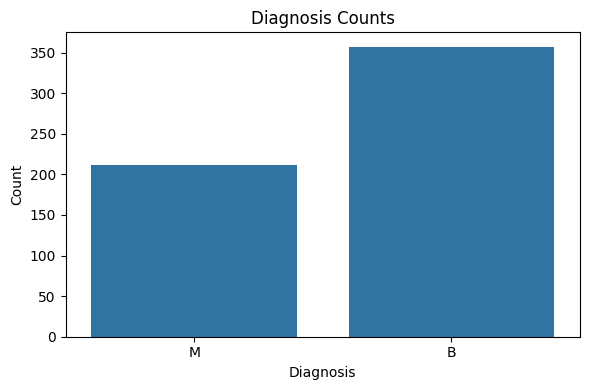


Top correlations with malignancy:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
compactness_mean        0.596534
compactness_worst       0.590998
radius_se               0.567134
perimeter_se            0.556141
area_se                 0.548236
Name: diagnosis_num, dtype: float64


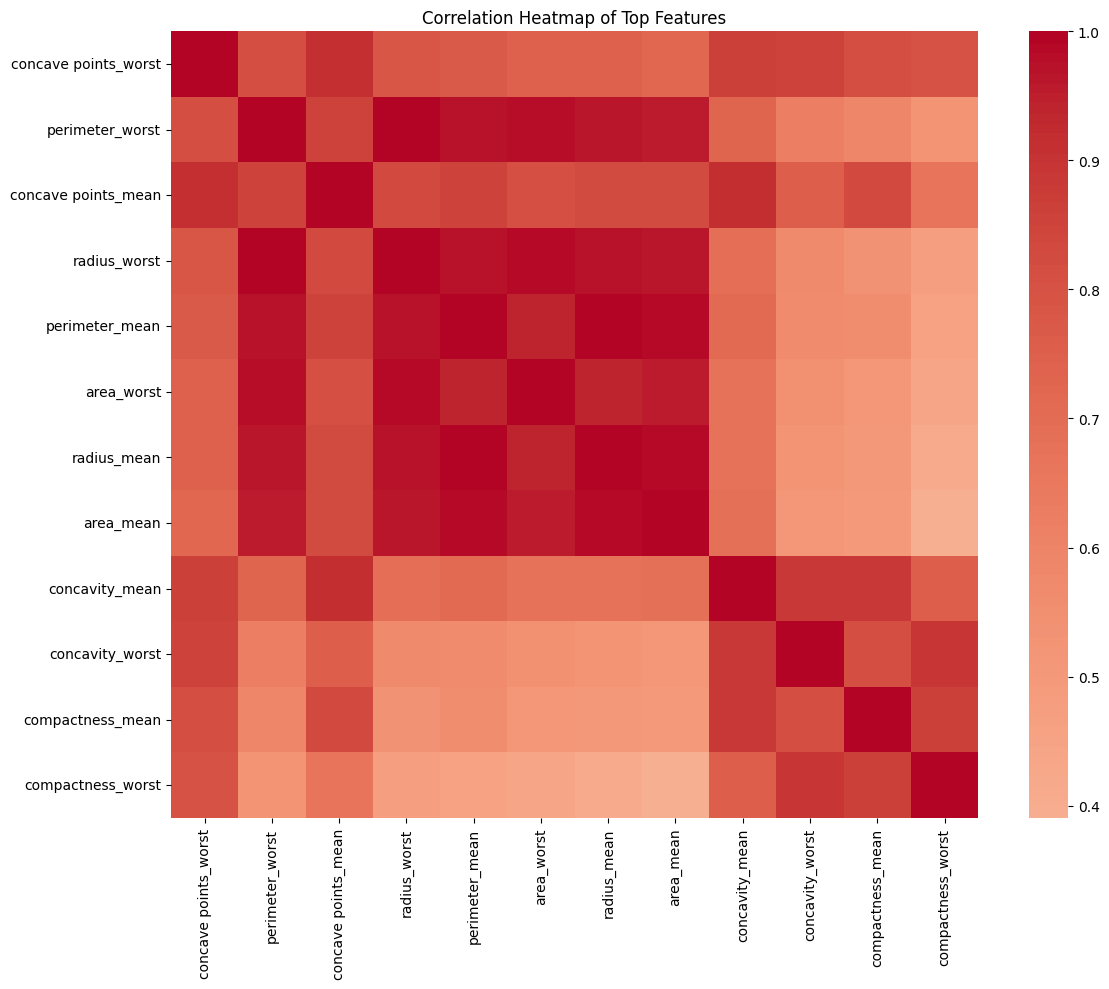


L1 Logistic Coefficients:
radius_se                  2.706052
area_worst                 2.434966
radius_worst               2.007194
texture_worst              1.778727
concave points_worst       1.251020
concavity_worst            1.108103
concave points_mean        1.097640
compactness_se            -0.875740
symmetry_worst             0.554144
smoothness_worst           0.547826
texture_se                -0.386619
smoothness_se              0.318290
fractal_dimension_se      -0.234605
fractal_dimension_mean    -0.123714
concavity_mean             0.114773
perimeter_worst            0.044636
area_se                    0.000000
texture_mean               0.000000
perimeter_mean             0.000000
area_mean                  0.000000
smoothness_mean            0.000000
compactness_mean           0.000000
radius_mean                0.000000
perimeter_se               0.000000
symmetry_mean              0.000000
concavity_se               0.000000
symmetry_se                0.000000
c

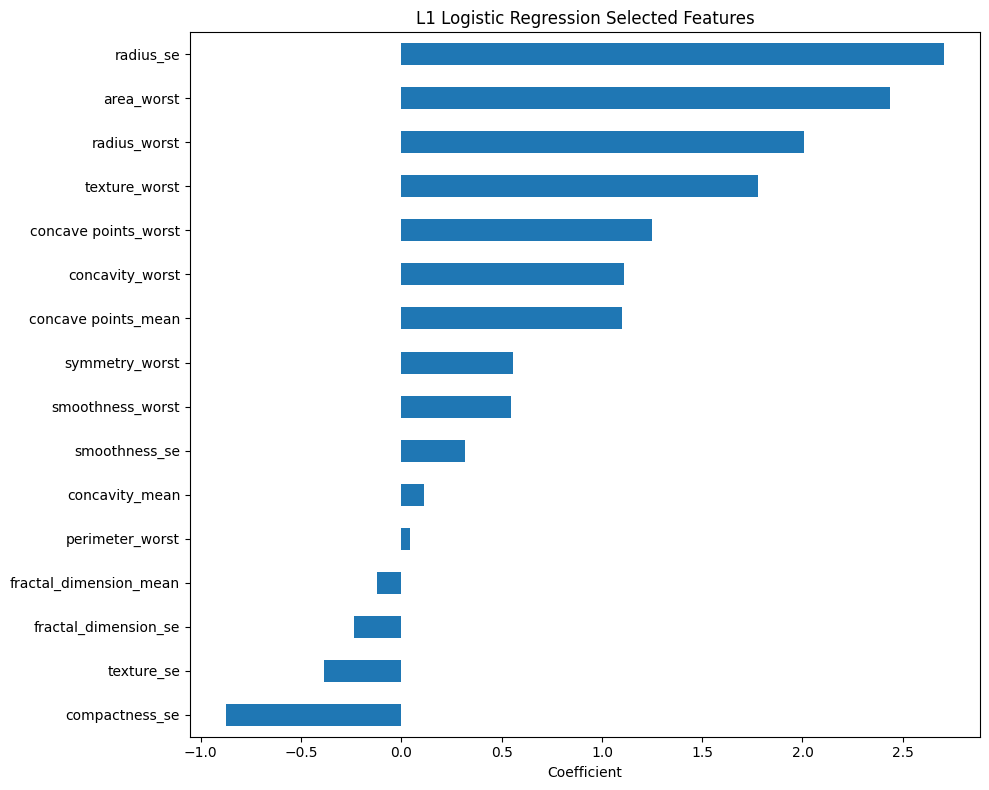

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

file_path = r"C:\Users\Colin Briggs\Downloads\data.csv"
df = pd.read_csv(file_path)

if "Unnamed: 32" in df.columns:
    df = df.drop(columns=["Unnamed: 32"])

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isna().sum())
print("\nDiagnosis counts:")
print(df["diagnosis"].value_counts())

df["diagnosis_num"] = df["diagnosis"].map({"B": 0, "M": 1})
feature_cols = [c for c in df.columns if c not in ["id", "diagnosis", "diagnosis_num"]]

summary_table = df[feature_cols].agg(["min", "max", "mean", "std"]).T
print("\nFeature ranges and summary stats:")
print(summary_table)

#save summary table if you want
summary_table.to_csv(r"C:\Users\Colin Briggs\Downloads\breast_cancer_feature_summary.csv")

#class balance plot
plt.figure(figsize=(6, 4))
sns.countplot(x="diagnosis", data=df)
plt.title("Diagnosis Counts")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#corr
corr_with_target = df[feature_cols + ["diagnosis_num"]].corr(numeric_only=True)["diagnosis_num"].drop("diagnosis_num")
corr_with_target = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)
print("\nTop correlations with malignancy:")
print(corr_with_target.head(15))

#heatmap
top12 = corr_with_target.head(12).index.tolist()

plt.figure(figsize=(12, 10))
sns.heatmap(df[top12].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Top Features")
plt.tight_layout()
plt.show()

#lasso
X = df[feature_cols]
y = df["diagnosis_num"]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

pipe.fit(X, y)

coefs = pd.Series(pipe.named_steps["model"].coef_[0], index=feature_cols)
coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index)

print("\nL1 Logistic Coefficients:")
print(coefs)

selected = coefs[coefs != 0]
print("\nSelected non-zero features:")
print(selected)

#plot selected coefficients
plt.figure(figsize=(10, 8))
selected.sort_values().plot(kind="barh")
plt.title("L1 Logistic Regression Selected Features")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()